# RSNA Knee Abnormality Detection

### Load data

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

    
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F

import pydicom

from src.tools import show_dicom_image, show_dicom_info


In [2]:
from pathlib import Path

print("Current directory:", Path.cwd())
print("Content:", list(Path.cwd().iterdir()))

Current directory: c:\projects\RSNA_Knee_Abnormality_Detection\notebook
Content: [WindowsPath('c:/projects/RSNA_Knee_Abnormality_Detection/notebook/rsna_analysis.ipynb')]


In [3]:
train_series =  Path("../data/train_series.csv")
train = Path("../data/train.csv")
train_series_dicom = Path("../data/train_series")


In [4]:
train_series_df = pd.read_csv(train_series)
train_df = pd.read_csv(train)

### View Data

In [5]:
display(train_series_df.head())

,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10077803906105306230...,1.2.826.0.1.3680043.8.498.25907331750467633841...,1,1,Sagittal
1,1.2.826.0.1.3680043.8.498.10077803906105306230...,1.2.826.0.1.3680043.8.498.35461930354143940974...,0,0,Sagittal
2,1.2.826.0.1.3680043.8.498.10077803906105306230...,1.2.826.0.1.3680043.8.498.59555639823582486217...,1,1,Axial
3,1.2.826.0.1.3680043.8.498.10077803906105306230...,1.2.826.0.1.3680043.8.498.74334922299557471072...,0,0,Coronal
4,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.10791858932231443712...,0,0,Sagittal


In [6]:
train_series_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 283 entries, 0 to 282
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   StudyInstanceUID   283 non-null    str  
 1   SeriesInstanceUID  283 non-null    str  
 2   Fluid_Sensitive    283 non-null    int64
 3   Fat_Suppression    283 non-null    int64
 4   Anatomical_Plane   283 non-null    str  
dtypes: int64(2), str(3)
memory usage: 11.2 KB


In [7]:
display(train_df.head())

,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.39500553372517290823...,Antecedentes Clínicos:\nArtrosis.\nHallazgos:\...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
1,1.2.826.0.1.3680043.8.498.63519003265636561965...,FINDINGS:\n\nFluid:\nModerate joint effusion. ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.12619895582462244920...,ΜΤ ΑΡΙΣΤΕΡΟΥ ΓΟΝΑΤΟΣ ΤΕΧΝΙΚΗ: Η εξέταση πραγμα...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.2.826.0.1.3680043.8.498.11249981834802444119...,Diz eklemi içi sıvı miktarı hafif derecede art...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.2.826.0.1.3680043.8.498.11382021393803389951...,"In the medial compartment, there is longitudi...",1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
with pd.option_context("display.max_colwidth", None):
    display(train_df[["Report"]].head(3))

,Report
0,"Antecedentes Clínicos:\nArtrosis.\nHallazgos:\nLigamentos cruzados y colaterales dentro de límites normales.\nEl menisco medial es de morfología y señal conservada, sin criterios categóricos de rotura.\nRotura compleja degenerativa del cuerno anterior, cuerpo, cuerno posterior y parte de la raíz\nmeniscal posterior del menisco lateral con extrusión asociada. Edema óseo periférico posterior de\nplatillo tibial lateral con pequeñas fracturas subcorticales regionales.\nÚlceras condrales de espesor parcial y total de la región posterior de carga del compartimento\nfemorotibial lateral. Mínimos cambios óseos asociados. Condropatía superficial del compartimento\nfemorotibial medial y del cartílago troclear.\nÚlceras condrales de espesor parcial y prácticamente total de la faceta lateral de la rótula.\nLeve a moderado derrame articular con mínima sinovitis. No hay quistes poplíteos patológicos.\nTendones cuadricipital, rotuliano, tendones de la pata de ganso, bíceps femoral y banda iliotibial\ndentro de límites normales.\nImpresión:\nRotura compleja degenerativa del cuerno anterior, cuerpo , cuerno posterior y raíz meniscal\nposterior del menisco lateral con extrusión asociada.\nCondropatía lesiones grado 3 y 4 del compartimento femorotibial lateral.\nCondropatía superficial del compartimento femorotibial medial y de la tróclea femoral. Condropatía\nlesiones grado dos y tres de la rótula.\nLeve a moderado derrame articular con mínima sinovitis"
1,"FINDINGS:\n\nFluid:\nModerate joint effusion. No popliteal cyst.\n\nMedial compartment (meniscus, collateral ligament, cartilage):\nNormal.\n\nLateral compartment (meniscus, collateral ligament complex, cartilage):\nNormal.\n\nIntercondylar compartment (anterior and posterior cruciate ligaments):\nComplete tear of the anterior cruciate ligament. Intact posterior cruciate ligament.\n\nAnterior compartment (extensor mechanism, cartilage, Hoffa's fat pad):\nFocal deep chondral fissure of the medial patellar facet without underlying bone marrow reactive changes.\n\nBones:\nMultifocal bone contusions involving the posterolateral tibial plateau and medial femoral condyle.\n\nMuscles and neurovascular structures:\nNormal.\n\nOther findings:\nNone\n\nCONCLUSION:\n1.Complete anterior cruciate ligament tear.\n2.Multifocal bone contusions involving the posterolateral tibial plateau and medial femoral condyle.\n3.Focal grade 3 chondropathy in the medial patellar facet.\n4.Moderate joint effusion."
2,"ΜΤ ΑΡΙΣΤΕΡΟΥ ΓΟΝΑΤΟΣ ΤΕΧΝΙΚΗ: Η εξέταση πραγματοποιήθηκε με ακολουθίες Τ1 σε στεφανιαίο επίπεδο και PDFS σε τρία επίπεδα. EYΡΗΜΑΤΑ: - Μετεγχειρητικές αλλοιώσεις στην άπω διάφυση του μηριαίου οστού. - Από τον έλεγχο του έσω διαμερίσματος αναγνωρίζεται λοξή οριζόντια ρήξη του σώματος του έσω μηνίσκου σε έδαφος εκφύλισης, λέπτυνση του αρθρικού χόνδρου (ICRS grade IV), επιχείλια οστεόφυτα και μικρής έκτασης υποχόνδρινο οστεομυελικό οίδημα του έσω μηριαίου κονδύλου. Συνυπάρχουν ευμεγέθη οστεόφυτα στον έσω μηριαίο κόνδυλο. - Από τον έλεγχο του έξω διαμερίσματος παρατηρείται λέπτυνση του αρθρικού χόνδρου (ICRS grade II) και επιχείλια οστεόφυτα. - Φυσιολογικοί απεικονίζονται οι πλάγιοι σύνδεσμοι άμφω και οι χιαστοί σύνδεσμοι. - Από τον έλεγχο του εκτατικού μηχανισμού, παρατηρούνται λέπτυνση και σχισμές του αρθρικού χόνδρου στην έσω επιφάνεια της επιγονατίδας και του μηριαίου κονδύλου, με συνοδό υποχόνδρινο οστεομυελικό οίδημα (ICRS grade IV). - Ελάχιστη συλλογή υγρού ενδοαρθρικά. Πολύχωρη συνοβιακή κύστη Baker κ-ο διαμέτρου 5,7εκ στην έσω ιγνυακή κοιλότητα. - Συρρέουσες ενδοστικές γαγγλιακές κύστεις στο επίπεδο του μεσοκονδύλιου επάρματος, αντίστοιχα με το επίπεδο πρόσφυσης του οπίσθιου χιαστού συνδέσμου. Συρρέσουσες συνοβιακές κύστεις επί τα εντός του οπίσθιου χιαστού συνδέσμου. ΣΥΜΠΕΡΑΣΜΑ: - Εκφυλιστική οστεοαρθρίτιδα κυρίως έσω και πρόσθιου διαμερίσματος"


In [8]:
train_series_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 283 entries, 0 to 282
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   StudyInstanceUID   283 non-null    str  
 1   SeriesInstanceUID  283 non-null    str  
 2   Fluid_Sensitive    283 non-null    int64
 3   Fat_Suppression    283 non-null    int64
 4   Anatomical_Plane   283 non-null    str  
dtypes: int64(2), str(3)
memory usage: 11.2 KB


In [9]:
from pathlib import Path

def explore_repository(root_path):
    root = Path(root_path)

    if not root.is_dir():
        raise NotADirectoryError(f"Invalid directory: {root}")

    print(f"{root.name}/")

    def explore(directory, prefix=""):
        items = sorted(
            directory.iterdir(),
            key=lambda x: (x.is_file(), x.name.lower())
        )

        for i, item in enumerate(items):
            is_last = i == len(items) - 1
            connector = "└── " if is_last else "├── "

            print(f"{prefix}{connector}{item.name}{'/' if item.is_dir() else ''}")

            if item.is_dir() and not item.is_symlink():
                extension = "    " if is_last else "│   "
                explore(item, prefix + extension)

    explore(root)

In [10]:

structure = explore_repository(train_series_dicom)

train_series/
├── 1.2.826.0.1.3680043.8.498.10077803906105306230229342168184970097/
│   ├── 1.2.826.0.1.3680043.8.498.25907331750467633841871804423069889144/
│   │   ├── 1.2.826.0.1.3680043.8.498.10509191872020439212262432575988735404.dcm
│   │   ├── 1.2.826.0.1.3680043.8.498.11615757242342140789291190074402336755.dcm
│   │   ├── 1.2.826.0.1.3680043.8.498.11657246400996556441789922026827353475.dcm
│   │   ├── 1.2.826.0.1.3680043.8.498.11988019715508839825597661686633945573.dcm
│   │   ├── 1.2.826.0.1.3680043.8.498.12266522998523156214482342882255533619.dcm
│   │   ├── 1.2.826.0.1.3680043.8.498.12562456289413060937693335390461923926.dcm
│   │   ├── 1.2.826.0.1.3680043.8.498.12581219857821389154064154597283117244.dcm
│   │   ├── 1.2.826.0.1.3680043.8.498.13373053488265781299638740841852082063.dcm
│   │   ├── 1.2.826.0.1.3680043.8.498.21182658538770857567268419610647685470.dcm
│   │   ├── 1.2.826.0.1.3680043.8.498.35705627980035647803400417405776842449.dcm
│   │   ├── 1.2.826.0.1.3680043.

In [11]:
def index_dicom_repository(root_path):

    root = Path(root_path)
    records = []

    for study_dir in sorted(root.iterdir()):

        if not study_dir.is_dir():
            continue

        for series_dir in sorted(study_dir.iterdir()):

            if not series_dir.is_dir():
                continue

            for dicom_file in series_dir.glob("*.dcm"):

                ds = pydicom.dcmread(
                    dicom_file,
                    stop_before_pixels=True
                )

                records.append({
                    "study_id": study_dir.name,
                    "series_id": series_dir.name,
                    "instance_id": dicom_file.stem,
                    "instance_number": ds.get("InstanceNumber"),
                    "modality": ds.get("Modality"),
                    "rows": ds.get("Rows"),
                    "columns": ds.get("Columns"),
                    "file_path": str(dicom_file)
                })

    return pd.DataFrame(records)

In [12]:
df_dicom = index_dicom_repository(train_series_dicom)


In [13]:
display(df_dicom.head(10)) , len(df_dicom)

,study_id,series_id,instance_id,instance_number,modality,rows,columns,file_path
0,1.2.826.0.1.3680043.8.498.10077803906105306230...,1.2.826.0.1.3680043.8.498.25907331750467633841...,1.2.826.0.1.3680043.8.498.10509191872020439212...,6,MR,384,384,..\data\train_series\1.2.826.0.1.3680043.8.498...
1,1.2.826.0.1.3680043.8.498.10077803906105306230...,1.2.826.0.1.3680043.8.498.25907331750467633841...,1.2.826.0.1.3680043.8.498.11615757242342140789...,10,MR,384,384,..\data\train_series\1.2.826.0.1.3680043.8.498...
2,1.2.826.0.1.3680043.8.498.10077803906105306230...,1.2.826.0.1.3680043.8.498.25907331750467633841...,1.2.826.0.1.3680043.8.498.11657246400996556441...,1,MR,384,384,..\data\train_series\1.2.826.0.1.3680043.8.498...
3,1.2.826.0.1.3680043.8.498.10077803906105306230...,1.2.826.0.1.3680043.8.498.25907331750467633841...,1.2.826.0.1.3680043.8.498.11988019715508839825...,17,MR,384,384,..\data\train_series\1.2.826.0.1.3680043.8.498...
4,1.2.826.0.1.3680043.8.498.10077803906105306230...,1.2.826.0.1.3680043.8.498.25907331750467633841...,1.2.826.0.1.3680043.8.498.12266522998523156214...,9,MR,384,384,..\data\train_series\1.2.826.0.1.3680043.8.498...
5,1.2.826.0.1.3680043.8.498.10077803906105306230...,1.2.826.0.1.3680043.8.498.25907331750467633841...,1.2.826.0.1.3680043.8.498.12562456289413060937...,15,MR,384,384,..\data\train_series\1.2.826.0.1.3680043.8.498...
6,1.2.826.0.1.3680043.8.498.10077803906105306230...,1.2.826.0.1.3680043.8.498.25907331750467633841...,1.2.826.0.1.3680043.8.498.12581219857821389154...,8,MR,384,384,..\data\train_series\1.2.826.0.1.3680043.8.498...
7,1.2.826.0.1.3680043.8.498.10077803906105306230...,1.2.826.0.1.3680043.8.498.25907331750467633841...,1.2.826.0.1.3680043.8.498.13373053488265781299...,2,MR,384,384,..\data\train_series\1.2.826.0.1.3680043.8.498...
8,1.2.826.0.1.3680043.8.498.10077803906105306230...,1.2.826.0.1.3680043.8.498.25907331750467633841...,1.2.826.0.1.3680043.8.498.21182658538770857567...,7,MR,384,384,..\data\train_series\1.2.826.0.1.3680043.8.498...
9,1.2.826.0.1.3680043.8.498.10077803906105306230...,1.2.826.0.1.3680043.8.498.25907331750467633841...,1.2.826.0.1.3680043.8.498.35705627980035647803...,5,MR,384,384,..\data\train_series\1.2.826.0.1.3680043.8.498...


(None, 7984)

In [14]:
df_dicom.iloc[0].file_path

'..\\data\\train_series\\1.2.826.0.1.3680043.8.498.10077803906105306230229342168184970097\\1.2.826.0.1.3680043.8.498.25907331750467633841871804423069889144\\1.2.826.0.1.3680043.8.498.10509191872020439212262432575988735404.dcm'

In [15]:
show_dicom_info(df_dicom.iloc[0].file_path)

,Attribute,Value
0,ImageType,"[ORIGINAL, PRIMARY, M, ND]"
1,SOPClassUID,1.2.840.10008.5.1.4.1.1.4
2,SOPInstanceUID,1.2.826.0.1.3680043.8.498.10509191872020439212...
3,Modality,MR
4,Manufacturer,SIEMENS
5,SeriesDescription,pd_tse_fs_sag_np
6,ManufacturerModelName,SonataVision
7,PatientID,717b910e-c9b
8,PatientSex,F
9,ScanningSequence,SE


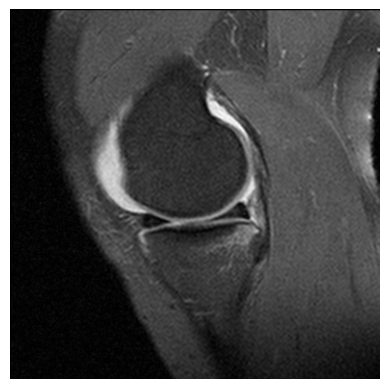

In [16]:
show_dicom_image(df_dicom.iloc[0].file_path)